Exploratory Data Analysis (EDA)


In [258]:
%matplotlib inline

import numpy as np
import pandas as pd
sales=pd.read_csv('../data/sales.csv')
print("Dataset Head:")
display(sales.head(10))

Dataset Head:


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882
5,687329,674,2,2013-03-19,1016,1,1,0,0,8406
6,600327,659,7,2014-06-08,0,0,0,0,0,0
7,96265,27,3,2014-07-16,1106,1,1,0,1,11162
8,364435,347,6,2013-05-11,448,1,0,0,0,5559
9,163146,288,2,2013-06-25,291,1,0,0,0,3997


In [285]:
sales.sample(12)

,date,nb_customers_on_day,open,promotion,state_holiday,sales
455402,2013-06-20,406,1,1,0,3802
455884,2014-12-28,0,0,0,0,0
65696,2013-02-01,930,1,0,0,10378
600940,2014-06-01,0,0,0,0,0
366054,2014-08-20,719,1,1,0,3976
120194,2015-06-03,399,1,1,0,4448
487271,2015-01-28,503,1,1,0,4152
526397,2013-12-25,0,0,0,c,0
439302,2013-10-13,0,0,0,0,0
421785,2014-10-29,570,1,0,0,6751


In [259]:
# What are the data types?
print("\nDataset Info:")
sales.info()
# 2. Inspect data types and non-null counts
print("\nDataset Info:")
sales.info()

# 3. Statistical summary of numeric features
print("\nSummary Statistics:")
display(sales.describe())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 55.6 MB

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


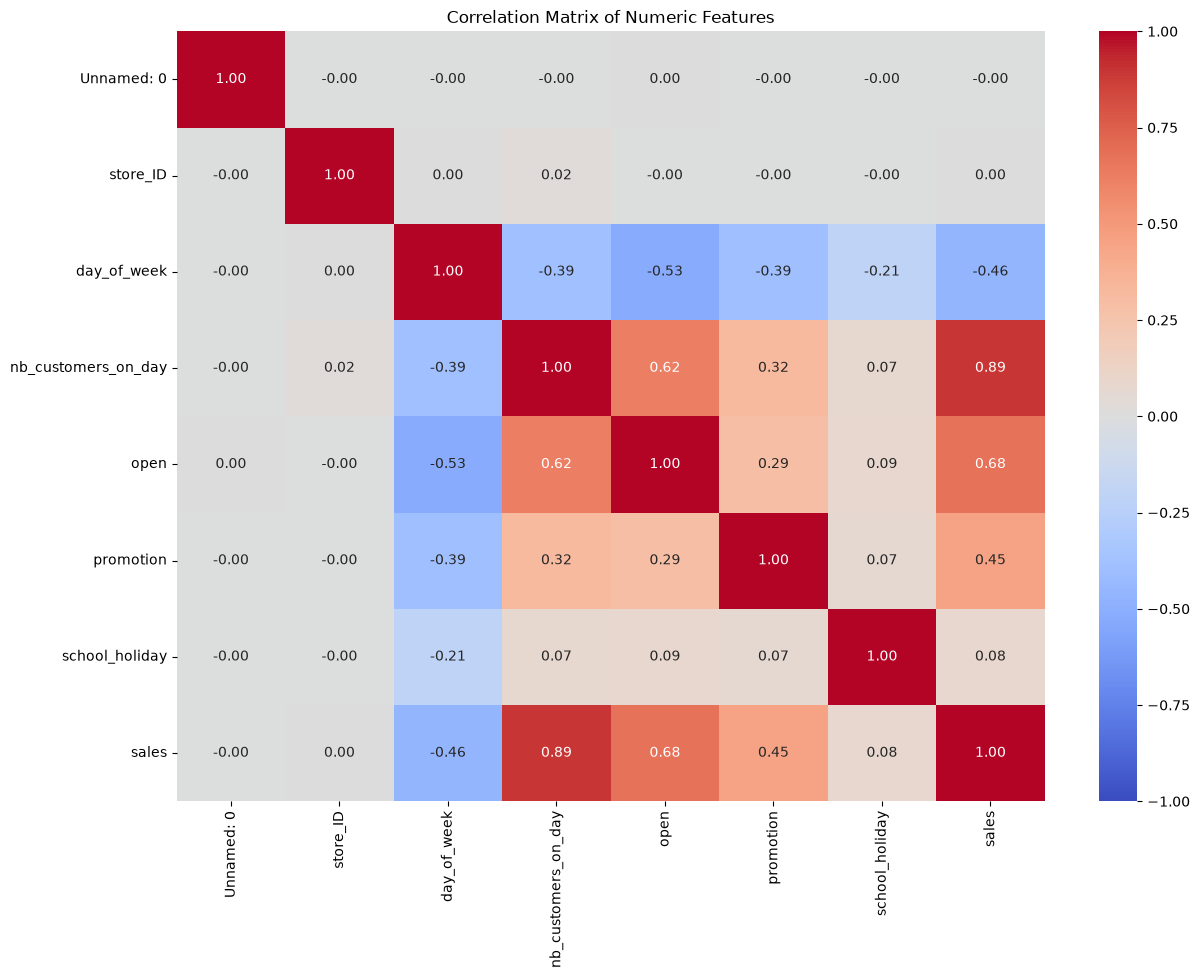

In [260]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Select numeric columns
numeric_df = sales.select_dtypes(include=[np.number])

# Calculate pairwise linear correlation matrix
corr_matrix = numeric_df.corr()

# Visualize correlation matrix with seaborn heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

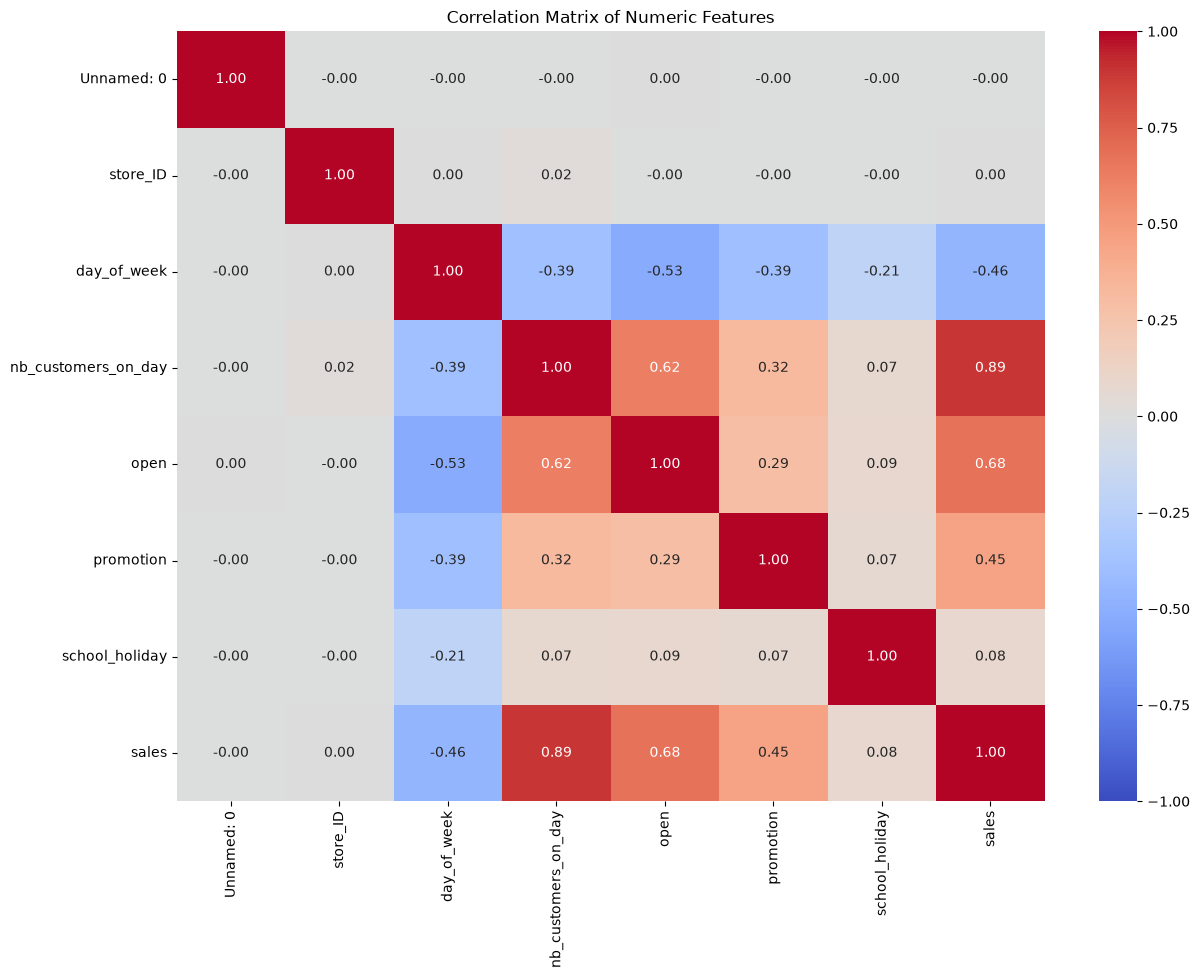

In [261]:
### 1. Code to Generate the Correlation Matrix & Heatmap


# Select numeric columns
numeric_df = sales.select_dtypes(include=[np.number])

# Calculate pairwise linear correlation matrix
corr_matrix = numeric_df.corr()

# Visualize correlation matrix with seaborn heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

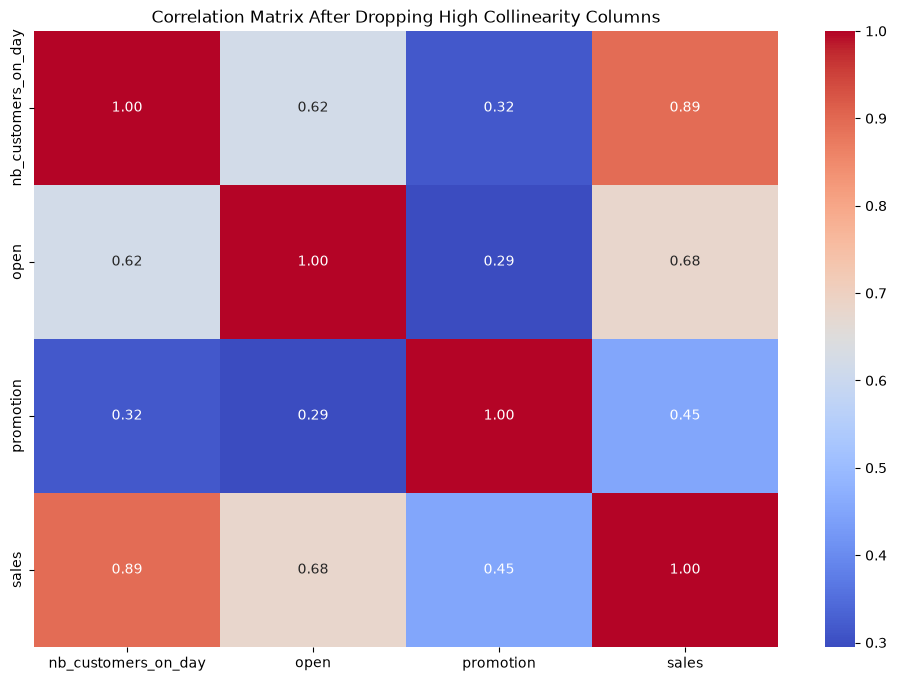

In [262]:
# Drop highly collinear redundant features (>0.90 correlation)
cols_to_drop = [
    "Unnamed: 0",
    "store_ID",
    "day_of_week",
    "school_holiday",
]
sales = sales.drop(columns=cols_to_drop)

# Re-evaluate correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    sales.select_dtypes(include=[np.number]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Correlation Matrix After Dropping High Collinearity Columns")
plt.show()

In [263]:
df = pd.read_csv("../data/sales.csv")
df.isna().sum()
print("\nMissing Values Count:")
print(df.isna().sum())


Missing Values Count:
Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


What's the target variable : sales 
What features look important : number of customers , promotions , open 
Do you need to handle class imbalance : no imbalance 
Do you need to convert data to the correct data type : not needed so far 
Do you need to handle missing values and/or outliers : no all data present 

In [264]:
from sklearn.linear_model import LinearRegression

In [265]:
from sklearn.model_selection import train_test_split

In [266]:
X = df.drop(columns=['Unnamed: 0', 'store_ID', 'day_of_week', 'school_holiday', 'sales'])
y = df['sales']

In [267]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [268]:
print('X_train shape:', X_train.shape)
print('X_val shape:  ', X_val.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (448588, 5)
X_val shape:   (96126, 5)
X_test shape:  (96126, 5)


In [269]:
split_class_balance = pd.DataFrame({
    'train (%)': (y_train.value_counts(normalize=True) * 100).round(2),
    'validation (%)': (y_val.value_counts(normalize=True) * 100).round(2),
    'test (%)': (y_test.value_counts(normalize=True) * 100).round(2)
})

split_class_balance

,train (%),validation (%),test (%)
sales,,,
0,17.01,16.93,16.92
46,0.00,NaN,NaN
124,0.00,NaN,NaN
316,NaN,NaN,0.00
530,NaN,NaN,0.00
...,...,...,...
38037,0.00,NaN,NaN
38367,NaN,0.00,NaN
38484,0.00,NaN,NaN


In [270]:
print(sales)

              date  nb_customers_on_day  open  promotion state_holiday  sales
0       2013-04-18                  517     1          0             0   4422
1       2015-04-11                  694     1          0             0   8297
2       2013-08-29                  970     1          1             0   9729
3       2013-05-28                  473     1          1             0   6513
4       2013-10-10                 1068     1          1             0  10882
...            ...                  ...   ...        ...           ...    ...
640835  2013-10-26                  483     1          0             0   4553
640836  2014-04-14                  987     1          1             0  12307
640837  2014-07-07                  925     1          0             0   6800
640838  2014-06-12                  725     1          0             0   5344
640839  2015-05-03                    0     0          0             0      0

[640840 rows x 6 columns]


In [271]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [272]:
majority_class = y_train.mode()[0]
print('Majority class in the training set:', majority_class)

baseline_model = DummyClassifier(strategy='most_frequent')
_ = baseline_model.fit(X_train_clean, y_train)

Majority class in the training set: 0


In [273]:
y_val_pred_baseline = baseline_model.predict(X_val_clean)

In [274]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

baseline_results = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R²'],
    'value': [
        mean_absolute_error(y_val, y_val_pred_baseline),
        np.sqrt(mean_squared_error(y_val, y_val_pred_baseline)),
        r2_score(y_val, y_val_pred_baseline)
    ]
})

baseline_results['value'] = baseline_results['value'].round(3)

baseline_results

,metric,value
0,MAE,5778.225
1,RMSE,6944.518
2,R²,-2.250


In [275]:
y_val.describe()

print("Mean sales:", y_val.mean())
print("Median sales:", y_val.median())
print("Min sales:", y_val.min())
print("Max sales:", y_val.max())

Mean sales: 5778.225433285479
Median sales: 5738.0
Min sales: 0
Max sales: 38367


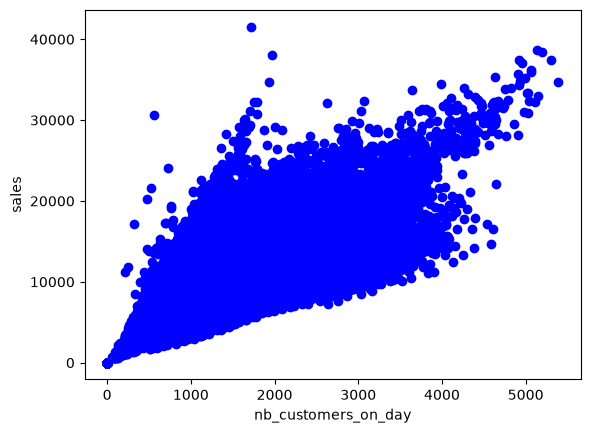

In [276]:
msk = np.random.rand(len(df)) < 0.8
train = df[msk]
test = df[~msk]

plt.scatter(train.nb_customers_on_day, train.sales,  color='blue')
plt.xlabel("nb_customers_on_day")
plt.ylabel("sales")
plt.show()

In [277]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['nb_customers_on_day']])
train_y = np.asanyarray(train[['sales']])
regr.fit(train_x, train_y)
# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [[7.42648559]]
Intercept:  [1071.69409378]


Text(0, 0.5, 'sales')

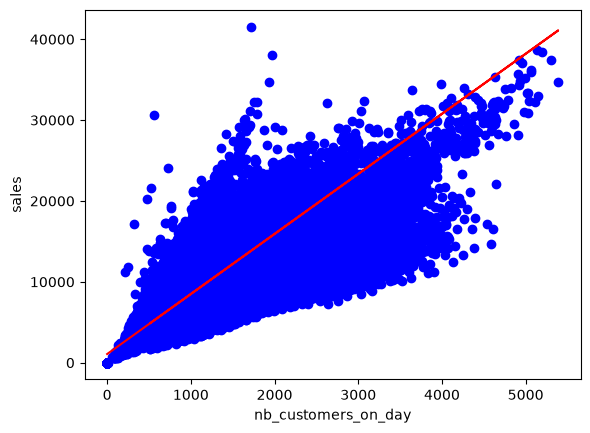

In [278]:
plt.scatter(train.nb_customers_on_day, train.sales,  color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("nb_customers_on_day")
plt.ylabel("sales")

In [279]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['nb_customers_on_day']])
test_y = np.asanyarray(test[['sales']])
test_y_ = regr.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y , test_y_) )

Mean absolute error: 1228.88
Residual sum of squares (MSE): 3006144.14
R2-score: 0.80
